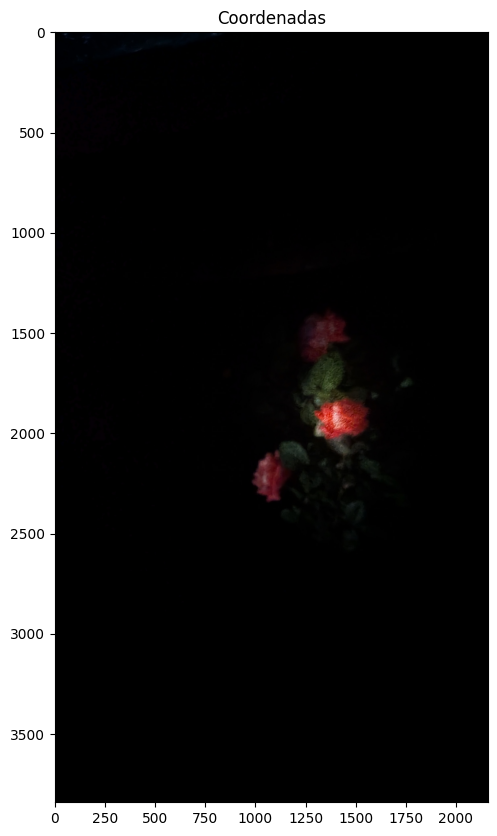

Forma: (3840, 2160, 3)


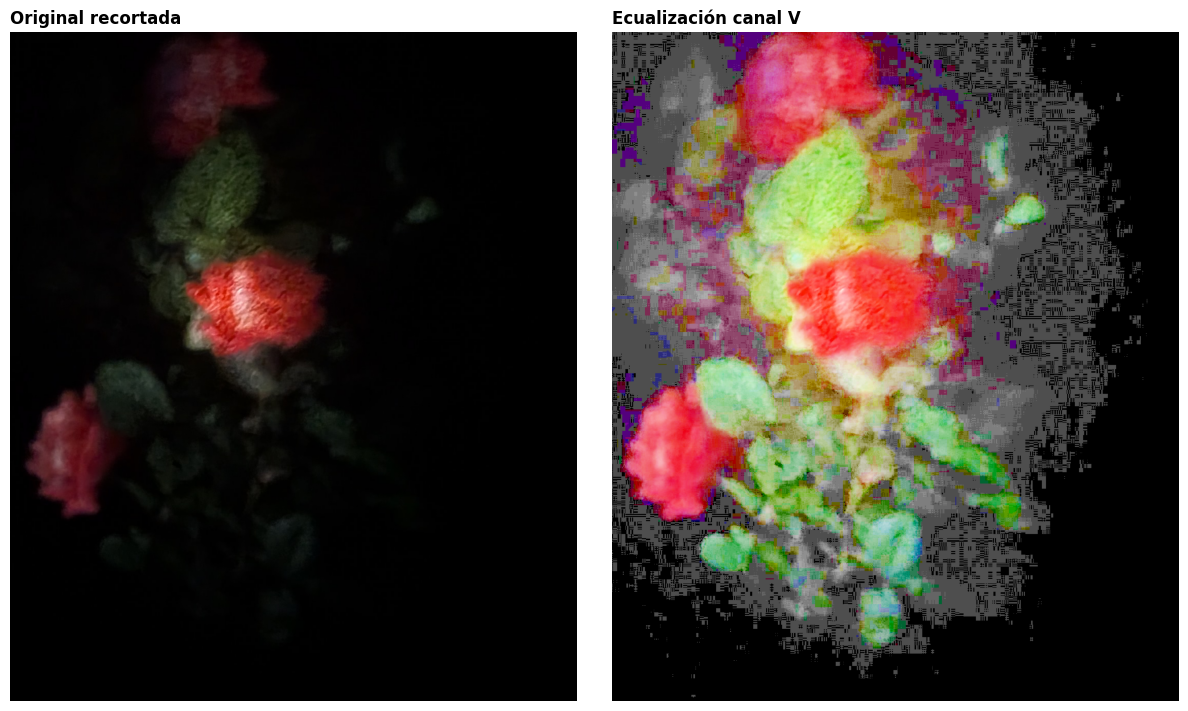

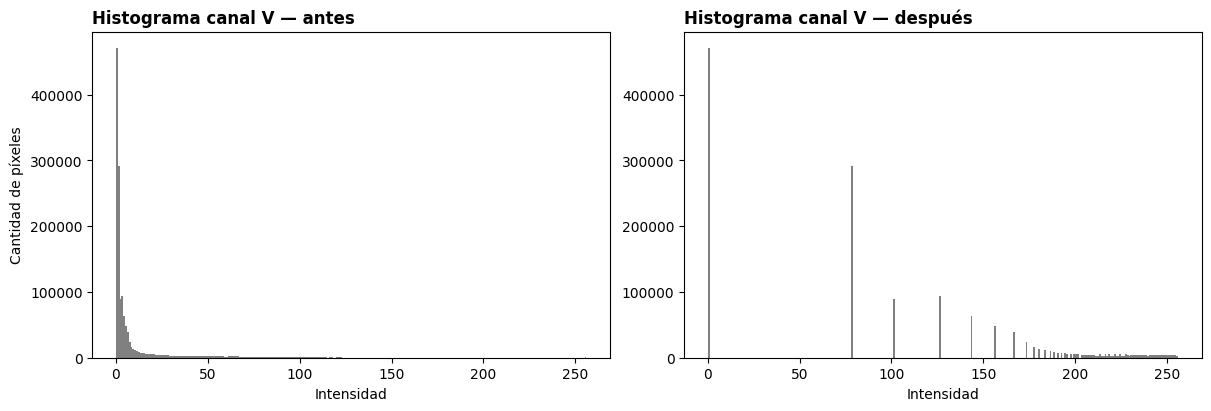

Guardada en: C:\Users\cin_c\OneDrive\Desktop\Repositorios\pdi\coronel-cintia-pdi-1c-2026\006_fotografia_digital\imagenes\procesadas\camara_oscura_ecualizada.jpg


In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ubicación de imagenes
carpeta_imagenes = Path("../imagenes/originales")
carpeta_salidas = Path("../imagenes/procesadas")
carpeta_salidas.mkdir(parents=True, exist_ok=True)

img_bgr = cv2.imread(str(carpeta_imagenes / "camara_oscura.jpg"))
if img_bgr is None:
    raise FileNotFoundError(f"No se encontró la imagen en: {(carpeta_imagenes / 'camara_oscura.jpg').resolve()}")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Veo el plano de coordenadas para analizar el recorte y quedarme con las rosas
plt.figure(figsize=(8, 10))
plt.imshow(img_rgb)
plt.title("Coordenadas")
plt.axis("on")
plt.show()
print("Forma:", img_rgb.shape)

# Recorte de imagen
img_recortada = img_rgb[1400:2700, 950:2050]

# Conversión a BGR para procesar con OpenCV
img_bgr_recortada = cv2.cvtColor(img_recortada, cv2.COLOR_RGB2BGR)

# Ecualización del canal V en espacio HSV
hsv = cv2.cvtColor(img_bgr_recortada, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
v_eq = cv2.equalizeHist(v)
hsv_eq = cv2.merge([h, s, v_eq])
img_eq_bgr = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2BGR)
img_eq_rgb = cv2.cvtColor(img_eq_bgr, cv2.COLOR_BGR2RGB)

# Comparación de imágenes
figura, ejes = plt.subplots(1, 2, figsize=(12, 7), constrained_layout=True)
ejes[0].imshow(img_recortada)
ejes[0].set_title("Original recortada", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(img_eq_rgb)
ejes[1].set_title("Ecualización canal V", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()

# Comparación de histogramas
figura2, ejes2 = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ejes2[0].hist(v.flatten(), bins=256, range=[0, 256], color="gray")
ejes2[0].set_title("Histograma canal V — antes", fontweight="bold", loc="left")
ejes2[0].set_xlabel("Intensidad")
ejes2[0].set_ylabel("Cantidad de píxeles")
ejes2[1].hist(v_eq.flatten(), bins=256, range=[0, 256], color="gray")
ejes2[1].set_title("Histograma canal V — después", fontweight="bold", loc="left")
ejes2[1].set_xlabel("Intensidad")
plt.show()

# Guardamos los resultados
cv2.imwrite(str(carpeta_salidas / "camara_oscura_ecualizada.jpg"), img_eq_bgr)
print(f"Guardada en: {(carpeta_salidas / 'camara_oscura_ecualizada.jpg').resolve()}")